### Import relevant libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Define useful fonctions

In [2]:
def run_ssm_kalman(X, y_init, Q_init, A, Q, C, R, mode='smooth'):
    """
    Calculates kalman-smoother estimates of SSM state posterior.
    :param X:       data, [d, t_max] numpy array
    :param y_init:  initial latent state, [k,] numpy array
    :param Q_init:  initial variance, [k, k] numpy array
    :param A:       latent dynamics matrix, [k, k] numpy array
    :param Q:       innovariations covariance matrix, [k, k] numpy array
    :param C:       output loading matrix, [d, k] numpy array
    :param R:       output noise matrix, [d, d] numpy array
    :param mode:    'forw' or 'filt' for forward filtering, 'smooth' for also backward filtering
    :return:
    y_hat:      posterior mean estimates, [k, t_max] numpy array
    V_hat:      posterior variances on y_t, [t_max, k, k] numpy array
    V_joint:    posterior covariances between y_{t+1}, y_t, [t_max, k, k] numpy array
    likelihood: conditional log-likelihoods log(p(x_t|x_{1:t-1})), [t_max,] numpy array
    """
    d, k = C.shape
    t_max = X.shape[1]

    # dimension checks
    assert np.all(X.shape == (d, t_max)), "Shape of X must be (%d, %d), %s provided" % (d, t_max, X.shape)
    assert np.all(y_init.shape == (k,)), "Shape of y_init must be (%d,), %s provided" % (k, y_init.shape)
    assert np.all(Q_init.shape == (k, k)), "Shape of Q_init must be (%d, %d), %s provided" % (k, k, Q_init.shape)
    assert np.all(A.shape == (k, k)), "Shape of A must be (%d, %d), %s provided" % (k, k, A.shape)
    assert np.all(Q.shape == (k, k)), "Shape of Q must be (%d, %d), %s provided" % (k, k, Q.shape)
    assert np.all(C.shape == (d, k)), "Shape of C must be (%d, %d), %s provided" % (d, k, C.shape)
    assert np.all(R.shape == (d, d)), "Shape of R must be (%d, %d), %s provided" % (d, k, R.shape)

    y_filt = np.zeros((k, t_max))  # filtering estimate: \hat(y)_t^t
    V_filt = np.zeros((t_max, k, k))  # filtering variance: \hat(V)_t^t
    y_hat = np.zeros((k, t_max))  # smoothing estimate: \hat(y)_t^T
    V_hat = np.zeros((t_max, k, k))  # smoothing variance: \hat(V)_t^T
    K = np.zeros((t_max, k, X.shape[0]))  # Kalman gain
    J = np.zeros((t_max, k, k))  # smoothing gain
    likelihood = np.zeros(t_max)  # conditional log-likelihood: p(x_t|x_{1:t-1})

    I_k = np.eye(k)

    # forward pass

    V_pred = Q_init
    y_pred = y_init

    for t in range(t_max):
        x_pred_err = X[:, t] - C.dot(y_pred)
        V_x_pred = C.dot(V_pred.dot(C.T)) + R
        V_x_pred_inv = np.linalg.inv(V_x_pred)
        likelihood[t] = -0.5 * (np.linalg.slogdet(2 * np.pi * (V_x_pred))[1] +
                                x_pred_err.T.dot(V_x_pred_inv).dot(x_pred_err))

        K[t] = V_pred.dot(C.T).dot(V_x_pred_inv)

        y_filt[:, t] = y_pred + K[t].dot(x_pred_err)
        V_filt[t] = V_pred - K[t].dot(C).dot(V_pred)

        # symmetrise the variance to avoid numerical drift
        V_filt[t] = (V_filt[t] + V_filt[t].T) / 2.0

        y_pred = A.dot(y_filt[:, t])
        V_pred = A.dot(V_filt[t]).dot(A.T) + Q

    # backward pass

    if mode == 'filt' or mode == 'forw':
        # skip if filtering/forward pass only
        y_hat = y_filt
        V_hat = V_filt
        V_joint = None
    else:
        V_joint = np.zeros_like(V_filt)
        y_hat[:, -1] = y_filt[:, -1]
        V_hat[-1] = V_filt[-1]

        for t in range(t_max - 2, -1, -1):
            J[t] = V_filt[t].dot(A.T).dot(np.linalg.inv(A.dot(V_filt[t]).dot(A.T) + Q))
            y_hat[:, t] = y_filt[:, t] + J[t].dot((y_hat[:, t + 1] - A.dot(y_filt[:, t])))
            V_hat[t] = V_filt[t] + J[t].dot(V_hat[t + 1] - A.dot(V_filt[t]).dot(A.T) - Q).dot(J[t].T)

        V_joint[-2] = (I_k - K[-1].dot(C)).dot(A).dot(V_filt[-2])

        for t in range(t_max - 3, -1, -1):
            V_joint[t] = V_filt[t + 1].dot(J[t].T) + J[t + 1].dot(V_joint[t + 1] - A.dot(V_filt[t + 1])).dot(J[t].T)

    return y_hat, V_hat, V_joint, likelihood

def is_positive_definite(A):
    """Check if matrix A is positive definite."""
    try:
        np.linalg.cholesky(A)
        return True
    except np.linalg.LinAlgError:
        return False

def logdet(A):
    """Compute the log-determinant of a matrix A, handling non-positive definite cases."""
    try:
        # Attempt Cholesky decomposition
        L = np.linalg.cholesky(A)
        return 2 * np.sum(np.log(np.diag(L)))
    except np.linalg.LinAlgError:
        # If not positive definite, add a small constant to the diagonal
        A += np.eye(A.shape[0]) * 1e-6
        L = np.linalg.cholesky(A)
        return 2 * np.sum(np.log(np.diag(L)))

### We define our input variables

In [3]:
X = np.loadtxt('ssm_spins.txt')

A = 0.99 * np.array([
    [np.cos(2 * np.pi / 180), -np.sin(2 * np.pi / 180), 0, 0],
    [np.sin(2 * np.pi / 180), np.cos(2 * np.pi / 180), 0, 0],
    [0, 0, np.cos(2 * np.pi / 90), -np.sin(2 * np.pi / 90)],
    [0, 0, np.sin(2 * np.pi / 90), np.cos(2 * np.pi / 90)]])

Q = np.eye(4) - A @ A.T

Q0=np.ones((4,4))

C = np.array([
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [0, 0, 1, 0],
    [0, 0, 1, 1],
    [0.5, 0.5, 0.5, 0.5]])

R = np.eye(5)

Y0 = np.random.normal(loc=0, scale=1, size=(4,))

### Run the filter and plot the figures

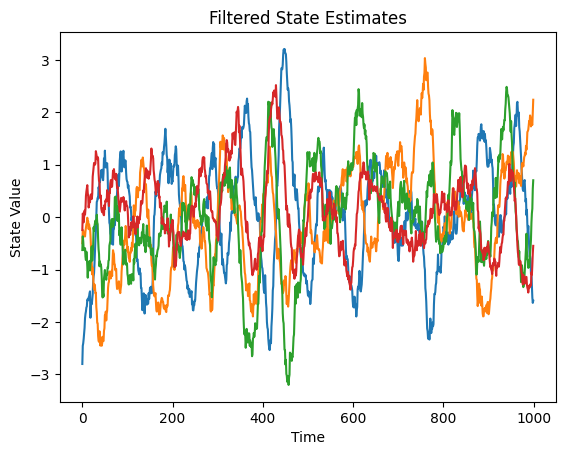

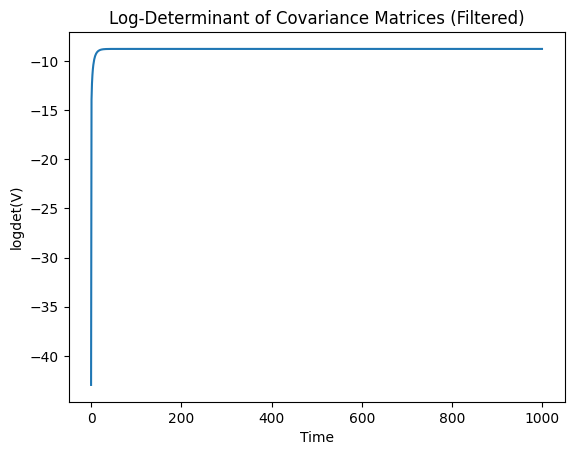

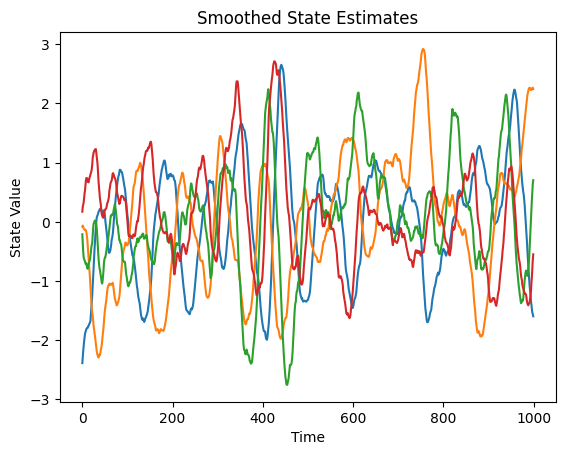

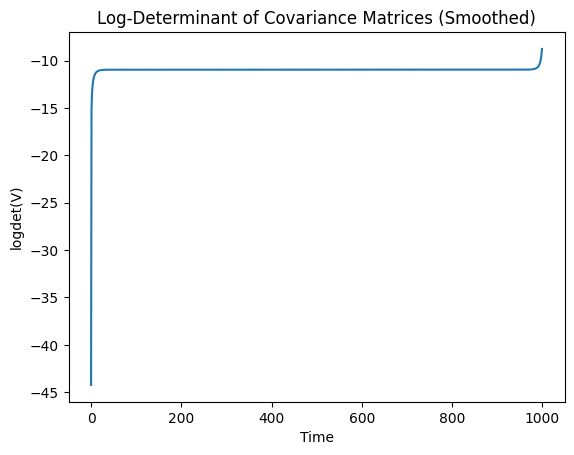

In [4]:
# Run ssm_kalman function with 'filt' option
Y, V, _, L = run_ssm_kalman(X.T, Y0, Q0, A, Q, C, R, 'filt')

# Plot Y
plt.figure()
plt.plot(Y.T)
plt.title("Filtered State Estimates")
plt.xlabel("Time")
plt.ylabel("State Value")
plt.show()

# Plot log-determinants of V (covariance matrices)
logdet_values_filt = [logdet(v) for v in V]
plt.figure()
plt.plot(logdet_values_filt)
plt.title("Log-Determinant of Covariance Matrices (Filtered)")
plt.xlabel("Time")
plt.ylabel("logdet(V)")
plt.show()

# Run ssm_kalman function with 'smooth' option
Y, V, Vj, L = run_ssm_kalman(X.T, Y0, Q0, A, Q, C, R, 'smooth')

# Plot Y
plt.figure()
plt.plot(Y.T)
plt.title("Smoothed State Estimates")
plt.xlabel("Time")
plt.ylabel("State Value")
plt.show()

# Plot log-determinants of V (smoothed covariance matrices)
logdet_values_smooth = [logdet(v) for v in V]
plt.figure()
plt.plot(logdet_values_smooth)
plt.title("Log-Determinant of Covariance Matrices (Smoothed)")
plt.xlabel("Time")
plt.ylabel("logdet(V)")
plt.show()
